In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
portfolio_tickers_sentiment =  pd.read_csv('data/v2tone_dataset.csv').round(2)
benchmark_sentiment = pd.read_csv('data/QQQ_2015_today.csv').round(2)
print(f"shape of portfolio_tickers_sentiment: {portfolio_tickers_sentiment.shape}")
print(f"columns of portfolio_tickers_sentiment: {portfolio_tickers_sentiment.columns}")
portfolio_tickers_sentiment.tail()

shape of portfolio_tickers_sentiment: (1316, 13)
columns of portfolio_tickers_sentiment: Index(['ticker', 'year', 'month', 'article_count', 'tone_mean',
       'positive_mean', 'negative_mean', 'finbert_sentiment',
       'confidence_level', 'sentiment_volatility', 'coverage_percentile',
       'sample_urls', 'sources_used'],
      dtype='object')


,ticker,year,month,article_count,tone_mean,positive_mean,negative_mean,finbert_sentiment,confidence_level,sentiment_volatility,coverage_percentile,sample_urls,sources_used
1311,VERU,2022,7,7,-1.27,3.32,4.59,-0.01,low,stable,0.00,[https://www.fool.com/investing/2022/07/11/why...,"[fool.com,marketwatch.com,thestreet.com]"
1312,VERU,2022,8,7,-1.35,2.28,3.63,-0.01,low,stable,0.00,[https://realmoney.thestreet.com/investing/sto...,"[thestreet.com,marketwatch.com,fool.com,busine..."
1313,VERU,2022,11,18,-1.96,2.51,4.47,-0.02,low,stable,1.00,[https://markets.businessinsider.com/news/stoc...,"[investors.com,marketwatch.com,businessinsider..."
1314,VERU,2022,12,8,-1.94,2.40,4.34,-0.02,low,stable,0.33,[https://markets.businessinsider.com/news/stoc...,"[fool.com,businessinsider.com,morningstar.com]"
1315,VERU,2023,3,12,-2.00,2.82,4.82,-0.02,low,stable,0.67,[https://www.morningstar.com/news/dow-jones/20...,"[marketwatch.com,morningstar.com,businessinsid..."


In [12]:
# Check data coverage period and identify any missing months
print("Data Coverage Analysis:")
print("=" * 50)

# Get date range for portfolio data
portfolio_dates = portfolio_tickers_sentiment[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])
portfolio_start = f"{portfolio_dates.iloc[0]['year']}-{portfolio_dates.iloc[0]['month']:02d}"
portfolio_end = f"{portfolio_dates.iloc[-1]['year']}-{portfolio_dates.iloc[-1]['month']:02d}"

# Get date range for benchmark data  
benchmark_dates = benchmark_sentiment[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])
benchmark_start = f"{benchmark_dates.iloc[0]['year']}-{benchmark_dates.iloc[0]['month']:02d}"
benchmark_end = f"{benchmark_dates.iloc[-1]['year']}-{benchmark_dates.iloc[-1]['month']:02d}"

print(f"Portfolio data period: {portfolio_start} to {portfolio_end}")
print(f"Benchmark data period: {benchmark_start} to {benchmark_end}")

# Create complete date range from 2015-01 to 2025-12
complete_dates = []
for year in range(2015, 2026):
    for month in range(1, 13):
        complete_dates.append({'year': year, 'month': month})
complete_df = pd.DataFrame(complete_dates)

# Check missing months in portfolio data
portfolio_missing = complete_df.merge(portfolio_dates, on=['year', 'month'], how='left', indicator=True)
portfolio_missing = portfolio_missing[portfolio_missing['_merge'] == 'left_only'][['year', 'month']]

# Check missing months in benchmark data
benchmark_missing = complete_df.merge(benchmark_dates, on=['year', 'month'], how='left', indicator=True)
benchmark_missing = benchmark_missing[benchmark_missing['_merge'] == 'left_only'][['year', 'month']]

print(f"\nPortfolio data covers {len(portfolio_dates)} months out of {len(complete_df)} possible months")
print(f"Missing months in portfolio data: {len(portfolio_missing)}")

print(f"\nBenchmark data covers {len(benchmark_dates)} months out of {len(complete_df)} possible months")
print(f"Missing months in benchmark data: {len(benchmark_missing)}")

if len(portfolio_missing) > 0:
    print(f"\nFirst 10 missing months in portfolio data:")
    print(portfolio_missing.head(10).to_string(index=False))

if len(benchmark_missing) > 0:
    print(f"\nFirst 10 missing months in benchmark data:")
    print(benchmark_missing.head(10).to_string(index=False))


Data Coverage Analysis:
Portfolio data period: 2015-02 to 2025-08
Benchmark data period: 2015-03 to 2025-07

Portfolio data covers 127 months out of 132 possible months
Missing months in portfolio data: 5

Benchmark data covers 78 months out of 132 possible months
Missing months in benchmark data: 54

First 10 missing months in portfolio data:
 year  month
 2015      1
 2025      9
 2025     10
 2025     11
 2025     12

First 10 missing months in benchmark data:
 year  month
 2015      1
 2015      2
 2015     10
 2016      1
 2016      3
 2016      4
 2017      2
 2017      3
 2017      4
 2017      5


In [13]:
def prepare_sentiment_data(df):
    # Create month_year string column for easier date handling
    df['month_year'] = df['year'].astype(str) + '-' + df['month'].astype(str)
    # Convert to datetime and format as YYYY-MM
    df['month_year'] = pd.to_datetime(df['month_year'], format='%Y-%m').dt.strftime('%Y-%m')
    return df[['ticker', 'month_year', 'tone_mean', 'positive_mean', 'negative_mean', 'article_count']]

tickers_sentiment = prepare_sentiment_data(portfolio_tickers_sentiment)
tickers_sentiment

,ticker,month_year,tone_mean,positive_mean,negative_mean,article_count
0,AEM,2015-02,1.01,2.65,1.64,9
1,AEM,2015-03,1.57,3.90,2.33,16
2,AEM,2015-04,-0.63,2.19,2.82,7
3,AEM,2015-05,0.68,3.00,2.31,23
4,AEM,2015-06,0.73,2.68,1.95,14
...,...,...,...,...,...,...
1311,VERU,2022-07,-1.27,3.32,4.59,7
1312,VERU,2022-08,-1.35,2.28,3.63,7
1313,VERU,2022-11,-1.96,2.51,4.47,18
1314,VERU,2022-12,-1.94,2.40,4.34,8


In [14]:
tickers = tickers_sentiment['ticker'].unique()
for ticker in tickers:
    ticker_sentiment = tickers_sentiment[tickers_sentiment['ticker'] == ticker]
    print(f"ticker: {ticker}, month_year: {ticker_sentiment.month_year.count()}, from {ticker_sentiment.month_year.min()} to {ticker_sentiment.month_year.max()}")


ticker: AEM, month_year: 56, from 2015-02 to 2024-07
ticker: AI, month_year: 26, from 2020-12 to 2025-07
ticker: AMD, month_year: 126, from 2015-03 to 2025-08
ticker: APP, month_year: 21, from 2021-04 to 2025-07
ticker: ASML, month_year: 65, from 2015-04 to 2025-07
ticker: GOOGL, month_year: 127, from 2015-02 to 2025-08
ticker: INGM, month_year: 7, from 2015-03 to 2019-08
ticker: IONQ, month_year: 14, from 2023-06 to 2025-07
ticker: MRVL, month_year: 125, from 2015-02 to 2025-07
ticker: MSFT, month_year: 127, from 2015-02 to 2025-08
ticker: MU, month_year: 126, from 2015-02 to 2025-07
ticker: NVDA, month_year: 127, from 2015-02 to 2025-08
ticker: PLTR, month_year: 91, from 2015-06 to 2025-08
ticker: PLUG, month_year: 125, from 2015-02 to 2025-07
ticker: QBTS, month_year: 6, from 2019-12 to 2025-07
ticker: RDDT, month_year: 116, from 2015-02 to 2025-07
ticker: RGTI, month_year: 10, from 2017-03 to 2025-07
ticker: SMR, month_year: 14, from 2023-10 to 2025-07
ticker: VERU, month_year: 7, 

In [15]:
benchmark_sentiment = prepare_sentiment_data(benchmark_sentiment)
benchmark_sentiment.tail()

,ticker,month_year,tone_mean,positive_mean,negative_mean,article_count
73,QQQ,2025-01,-0.48,2.16,2.64,7
74,QQQ,2025-03,-2.92,1.81,4.72,14
75,QQQ,2025-04,-0.20,2.33,2.53,15
76,QQQ,2025-05,0.86,2.83,1.97,9
77,QQQ,2025-07,1.17,3.41,2.24,13


In [16]:
# Concatenate horizontally (side by side)
combined_data = pd.concat([tickers_sentiment, benchmark_sentiment], axis=0)
print(f"shape of combined_data: {combined_data.shape}")


shape of combined_data: (1394, 6)


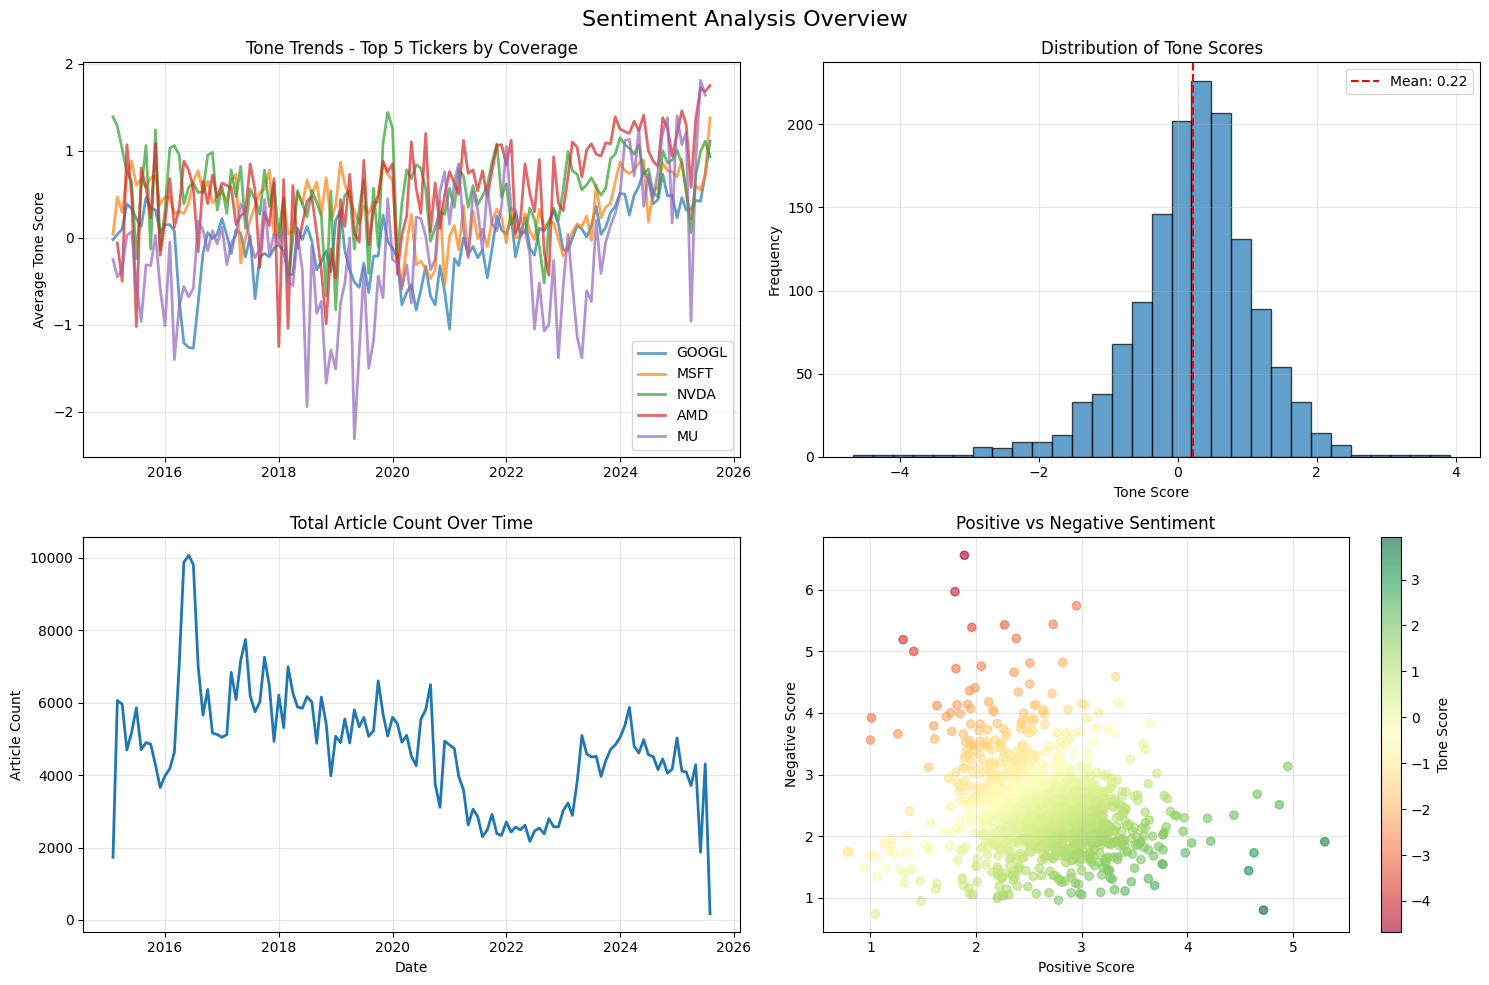

In [17]:
# Plot sentiment trends for each ticker over time
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sentiment Analysis Overview', fontsize=16)

df = combined_data.copy()

# Plot 1: Tone trends over time for top tickers by article count
ax1 = axes[0, 0]
top_tickers = df.groupby('ticker')['article_count'].sum().nlargest(5).index
for ticker in top_tickers:
    ticker_data = df[df['ticker'] == ticker].copy()
    ticker_data['date'] = pd.to_datetime(ticker_data['month_year'])
    ax1.plot(ticker_data['date'], ticker_data['tone_mean'], label=ticker, alpha=0.7, linewidth=2)
ax1.set_title('Tone Trends - Top 5 Tickers by Coverage')
ax1.set_ylabel('Average Tone Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of tone scores
ax2 = axes[0, 1]
ax2.hist(df['tone_mean'], bins=30, alpha=0.7, edgecolor='black')
ax2.axvline(df['tone_mean'].mean(), color='red', linestyle='--', label=f'Mean: {df["tone_mean"].mean():.2f}')
ax2.set_title('Distribution of Tone Scores')
ax2.set_xlabel('Tone Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Article count trends over time
ax3 = axes[1, 0]
monthly_articles = df.groupby('month_year')['article_count'].sum().reset_index()
monthly_articles['date'] = pd.to_datetime(monthly_articles['month_year'])
ax3.plot(monthly_articles['date'], monthly_articles['article_count'], linewidth=2)
ax3.set_title('Total Article Count Over Time')
ax3.set_ylabel('Article Count')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

# Plot 4: Positive vs Negative sentiment scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df['positive_mean'], df['negative_mean'], 
                     c=df['tone_mean'], cmap='RdYlGn', alpha=0.6)
ax4.set_xlabel('Positive Score')
ax4.set_ylabel('Negative Score')
ax4.set_title('Positive vs Negative Sentiment')
plt.colorbar(scatter, ax=ax4, label='Tone Score')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import ttest_ind
from scipy.stats import pearsonr



# Aggregate tone_mean by ticker and month_year
tickers_sentiment_agg = tickers_sentiment.groupby(['month_year'])['tone_mean'].mean().reset_index(name='portfolio_tone_mean')
benchmark_sentiment_agg = benchmark_sentiment[['month_year', 'tone_mean']].rename(columns={'tone_mean': 'benchmark_tone_mean'})
combined_data = pd.merge(tickers_sentiment_agg, benchmark_sentiment_agg, on='month_year', how='inner')

# --- t-test for difference in mean sentiment ---
# Comparing portfolio sentiment vs benchmark sentiment (independent samples t-test)
t_stat, p_val = ttest_ind(combined_data["portfolio_tone_mean"], combined_data["benchmark_tone_mean"])
print(f"T-stat: {t_stat:.3f}, p-value: {p_val:.4f}")



T-stat: 4.094, p-value: 0.0001


    T-test (difference in means)
    T-stat = 4.094, p-value = 0.0001 (< 0.05)
    👉 Reject H₀.
    👉 The mean monthly sentiment of your portfolio is statistically different from the benchmark.
    ✅ This means your sentiment dataset carries unique information and is not just replicating the benchmark’s sentiment.

In [27]:
from scipy.stats import ttest_rel, wilcoxon, spearmanr, brunnermunzel

# paired differences by month
d = combined_data["portfolio_tone_mean"] - combined_data["benchmark_tone_mean"]

# Paired t-test (parametric)
t_stat_paired, p_val_paired = ttest_rel(
    combined_data["portfolio_tone_mean"], combined_data["benchmark_tone_mean"]
)

# Wilcoxon signed-rank (non-parametric, paired)
# (drops zero-differences automatically)
w_stat, p_val_wilcox = wilcoxon(d, alternative="two-sided")

# Spearman correlation (rank-based, robust to non-normality)
rho, p_rho = spearmanr(
    combined_data["portfolio_tone_mean"], combined_data["benchmark_tone_mean"]
)

print(f"Paired t-test:     t={t_stat_paired:.3f}, p={p_val_paired:.4g}")
print(f"Wilcoxon test:     W={w_stat:.3f}, p={p_val_wilcox:.4g}")
print(f"Spearman corr:     rho={rho:.3f}, p={p_rho:.4g}")

# Optional: effect size for paired test (Cohen's d for paired samples)
cohens_d_paired = d.mean() / d.std(ddof=1)
print(f"Cohen's d (paired): {cohens_d_paired:.3f}")
# --- correlation test ---
# Measuring linear relationship between portfolio and benchmark sentiment
corr, p_corr = pearsonr(combined_data["portfolio_tone_mean"], combined_data["benchmark_tone_mean"])
print(f"Correlation: {corr:.3f}, p-value: {p_corr:.4f}")


Paired t-test:     t=4.596, p=1.657e-05
Wilcoxon test:     W=670.000, p=1.453e-05
Spearman corr:     rho=0.297, p=0.008242
Cohen's d (paired): 0.520
Correlation: 0.294, p-value: 0.0089


    What the tests say
    Paired t-test: t=4.596, p=1.657e-05 ⇒ reject H₀.
    Your portfolio’s monthly sentiment differs in level from the benchmark.
    Wilcoxon signed-rank: W=670, p=1.453e-05 ⇒ non-parametric confirmation of the same conclusion (robust to non-normality).
    Effect size (Cohen’s d, paired): 0.52 ⇒ medium practical difference.
    (From your earlier table the mean gap is ≈ +0.39 in sentiment units, portfolio > benchmark.)
    Correlation (Pearson=0.294, p=0.0089; Spearman=0.297, p=0.0082): weak but significant positive co-movement.
    ⇒ They share some market mood, but your portfolio sentiment is far from redundant.
    Plain-English conclusion
    Your portfolio sentiment is meaningfully higher and statistically different from the benchmark, and only loosely moves with it. That’s exactly what you want: unique signal rather than just broad market sentiment.